# Fase 1 — Cinematica del Balancin (Clase I, API Spec 11E)

**Objetivo**: Resolver el cuadrilatero articulado ciguenal-biela-balancin para obtener la posicion, velocidad, aceleracion y factor de torque de la varilla pulida en funcion del angulo del ciguenal $\theta$.

**Sistema de coordenadas**: Saddle bearing (pivote del balancin) en el origen. Centro del ciguenal en $(I, -H)$.

**Parametros de la unidad**: C-228D-200-86 (caso de prueba, Seccion 6.2 del documento).

## Ecuaciones clave

$$\text{Crank pin:} \quad (x_{cp}, y_{cp}) = (I + R\cos\theta,\; -H + R\sin\theta)$$

$$J(\theta) = \sqrt{x_{cp}^2 + y_{cp}^2}$$

$$\psi_b(\theta) = \arccos\left(\frac{C^2 + J^2 - P^2}{2CJ}\right)$$

$$y_{PR}(\theta) = -\frac{A}{C}\, y_E \quad\text{donde}\quad y_E = C\sin(\varphi + \psi_b)$$

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from aib_simulator.params import (
    A_beam, C_beam, I_geom, H_geom, P_pitman, R_crank,
    SPM_nominal, S_stroke, g
)
from aib_simulator.geometry import (
    crank_pin, polished_rod_position, compute_kinematics,
    full_kinematics, mechanism_positions
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Parametros de la geometria
A, C, I, H, P, R = A_beam, C_beam, I_geom, H_geom, P_pitman, R_crank
print(f"Geometria C-228D-200-86 (Clase I):")
print(f"  A = {A:.3f} m  (brazo delantero)")
print(f"  C = {C:.3f} m  (brazo trasero)")
print(f"  I = {I:.3f} m  (offset horizontal)")
print(f"  H = {H:.3f} m  (offset vertical)")
print(f"  P = {P:.3f} m  (pitman)")
print(f"  R = {R:.3f} m  (manivela)")
print(f"  Carrera teorica S = 2R(A/C) = {2*R*A/C:.3f} m")

Geometria C-228D-200-86 (Clase I):
  A = 4.000 m  (brazo delantero)
  C = 2.500 m  (brazo trasero)
  I = 2.000 m  (offset horizontal)
  H = 4.500 m  (offset vertical)
  P = 3.500 m  (pitman)
  R = 0.900 m  (manivela)
  Carrera teorica S = 2R(A/C) = 2.880 m


## 1. Posicion de la varilla pulida $y_{PR}(\theta)$

Carrera real:    S = 2.8883 m
Carrera teorica: S = 2.8800 m
Diferencia:      0.29%
TDC (max y_PR):  theta = 279.2 deg
BDC (min y_PR):  theta = 83.5 deg
y_PR rango:      [0.2050, 3.0933] m


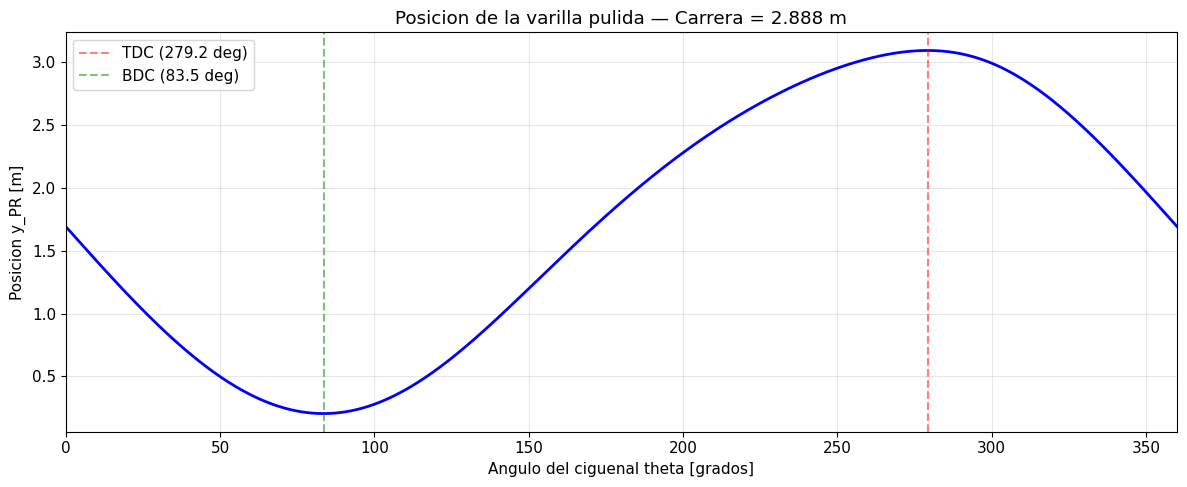

In [ ]:
# Barrido de un ciclo completo (0 a 2*pi)
theta = np.linspace(0, 2 * np.pi, 3600)  # 0.1 grado de resolucion

y_PR = polished_rod_position(theta, A, C, I, H, P, R)

# Carrera real
stroke = np.max(y_PR) - np.min(y_PR)
theta_TDC = theta[np.argmax(y_PR)]
theta_BDC = theta[np.argmin(y_PR)]

print(f"Carrera real:    S = {stroke:.4f} m")
print(f"Carrera teorica: S = {2*R*A/C:.4f} m")
print(f"Diferencia:      {abs(stroke - 2*R*A/C)/stroke*100:.2f}%")
print(f"TDC (max y_PR):  theta = {np.degrees(theta_TDC):.1f} deg")
print(f"BDC (min y_PR):  theta = {np.degrees(theta_BDC):.1f} deg")
print(f"y_PR rango:      [{np.min(y_PR):.4f}, {np.max(y_PR):.4f}] m")

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(np.degrees(theta), y_PR, 'b-', linewidth=2)
ax.axvline(np.degrees(theta_TDC), color='r', linestyle='--', alpha=0.5, label=f'TDC ({np.degrees(theta_TDC):.1f} deg)')
ax.axvline(np.degrees(theta_BDC), color='g', linestyle='--', alpha=0.5, label=f'BDC ({np.degrees(theta_BDC):.1f} deg)')
ax.set_xlabel('Angulo del ciguenal theta [grados]')
ax.set_ylabel('Posicion y_PR [m]')
ax.set_title(f'Posicion de la varilla pulida — Carrera = {stroke:.3f} m')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 360)
plt.tight_layout()
plt.show()

## 2. Velocidad, aceleracion y factor de torque

$$v_{PR} = \frac{dy_{PR}}{d\theta}\,\dot\theta = TF \cdot \omega$$

$$a_{PR} = \frac{d^2 y_{PR}}{d\theta^2}\,\omega^2 \quad (\text{con } \omega \text{ constante})$$

$$TF(\theta) = \frac{dy_{PR}}{d\theta} \quad [\text{m/rad}]$$

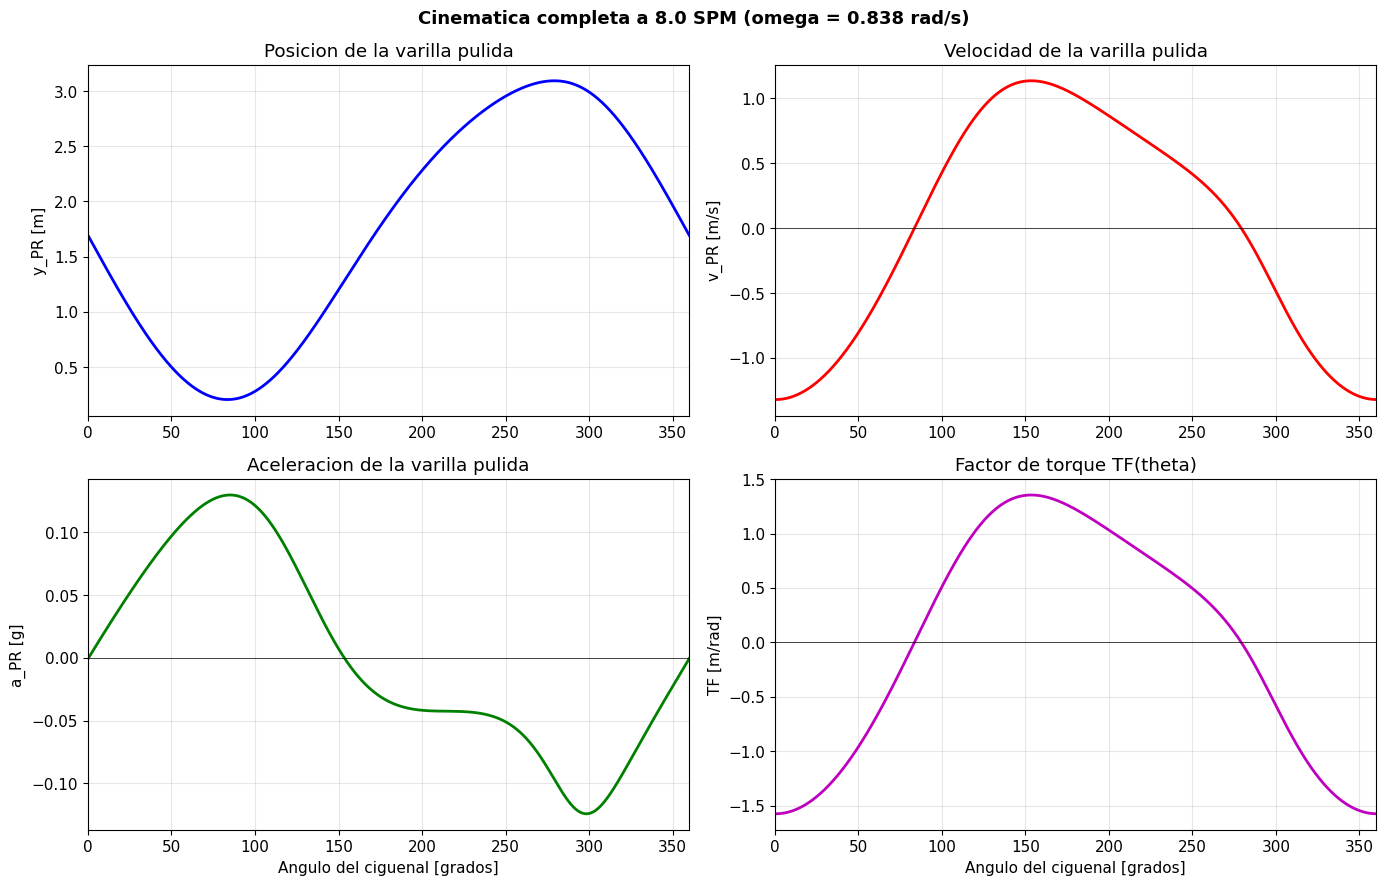


--- Valores caracteristicos ---
v_PR max = 1.1346 m/s
v_PR min = -1.3202 m/s
|a_PR| max = 0.1297 g
TF max = 1.3543 m/rad
TF min = -1.5758 m/rad


In [ ]:
# Cinematica completa a 8 SPM
omega_crank = 2 * np.pi * SPM_nominal / 60  # rad/s
kin = full_kinematics(theta, omega_crank, A, C, I, H, P, R)

y_PR = kin['y_PR']
v_PR = kin['v_PR']
a_PR = kin['a_PR']
TF   = kin['TF']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Posicion
ax = axes[0, 0]
ax.plot(np.degrees(theta), y_PR, 'b-', linewidth=2)
ax.set_ylabel('y_PR [m]')
ax.set_title('Posicion de la varilla pulida')
ax.grid(True, alpha=0.3)

# Velocidad
ax = axes[0, 1]
ax.plot(np.degrees(theta), v_PR, 'r-', linewidth=2)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel('v_PR [m/s]')
ax.set_title('Velocidad de la varilla pulida')
ax.grid(True, alpha=0.3)

# Aceleracion
ax = axes[1, 0]
ax.plot(np.degrees(theta), a_PR / g, 'g-', linewidth=2)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Angulo del ciguenal [grados]')
ax.set_ylabel('a_PR [g]')
ax.set_title('Aceleracion de la varilla pulida')
ax.grid(True, alpha=0.3)

# Factor de torque
ax = axes[1, 1]
ax.plot(np.degrees(theta), TF, 'm-', linewidth=2)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Angulo del ciguenal [grados]')
ax.set_ylabel('TF [m/rad]')
ax.set_title('Factor de torque TF(theta)')
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlim(0, 360)

plt.suptitle(f'Cinematica completa a {SPM_nominal} SPM (omega = {omega_crank:.3f} rad/s)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n--- Valores caracteristicos ---")
print(f"v_PR max = {np.max(v_PR):.4f} m/s")
print(f"v_PR min = {np.min(v_PR):.4f} m/s")
print(f"|a_PR| max = {np.max(np.abs(a_PR))/g:.4f} g")
print(f"TF max = {np.max(TF):.4f} m/rad")
print(f"TF min = {np.min(TF):.4f} m/rad")

## 3. Asimetria upstroke / downstroke

En una unidad Clase I, el upstroke y el downstroke no son simetricos debido a la geometria del cuadrilatero articulado. Se mide la duracion angular de cada semi-ciclo.

In [ ]:
# Asimetria: duracion angular del upstroke vs downstroke
# El upstroke va de BDC a TDC, el downstroke de TDC a BDC.

idx_TDC = np.argmax(y_PR)
idx_BDC = np.argmin(y_PR)

theta_TDC_deg = np.degrees(theta[idx_TDC])
theta_BDC_deg = np.degrees(theta[idx_BDC])

# Upstroke: BDC → TDC (en la direccion de avance de theta)
if theta_TDC_deg > theta_BDC_deg:
    upstroke_deg = theta_TDC_deg - theta_BDC_deg
else:
    upstroke_deg = 360 - theta_BDC_deg + theta_TDC_deg

downstroke_deg = 360 - upstroke_deg
asymmetry_deg = upstroke_deg - downstroke_deg

print(f"TDC en theta = {theta_TDC_deg:.1f} deg")
print(f"BDC en theta = {theta_BDC_deg:.1f} deg")
print(f"Upstroke:   {upstroke_deg:.1f} deg")
print(f"Downstroke: {downstroke_deg:.1f} deg")
print(f"Asimetria:  {asymmetry_deg:.1f} deg (esperado: 5-15 deg para Clase I)")

TDC en theta = 279.2 deg
BDC en theta = 83.5 deg
Upstroke:   195.7 deg
Downstroke: 164.3 deg
Asimetria:  31.3 deg (esperado: 5-15 deg para Clase I)


## 4. Visualizacion del mecanismo

Esquema del cuadrilatero articulado en varias posiciones del ciclo.

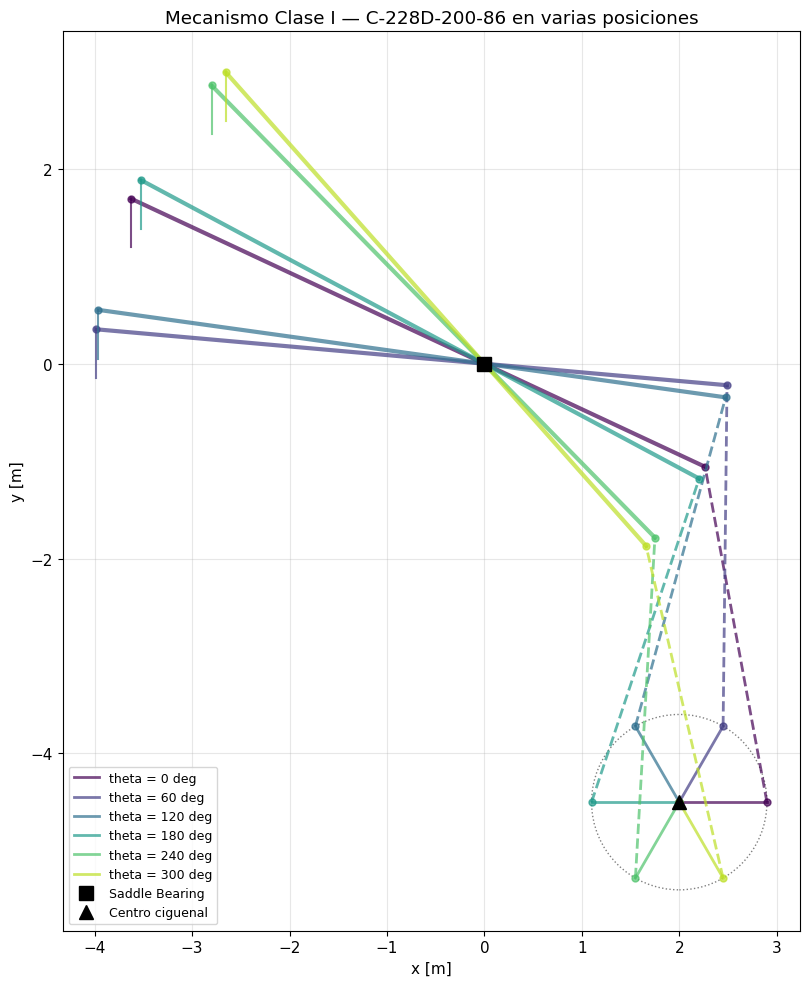

In [ ]:
def draw_mechanism(ax, theta_val, A, C, I, H, P, R, color='b', alpha=1.0, label=None):
    """Dibuja el mecanismo para un angulo theta dado."""
    pos = mechanism_positions(theta_val, A, C, I, H, P, R)
    
    cc = pos['crank_center']
    cp = pos['crank_pin']
    sb = pos['saddle_bearing']
    eb = pos['equalizer']
    hh = pos['horsehead']
    
    # Manivela (crank center → crank pin)
    ax.plot([cc[0], cp[0]], [cc[1], cp[1]], color=color, linewidth=2, alpha=alpha)
    # Biela (crank pin → equalizer bearing)
    ax.plot([cp[0], eb[0]], [cp[1], eb[1]], color=color, linewidth=2, alpha=alpha, linestyle='--')
    # Balancin (horsehead → saddle bearing → equalizer)
    ax.plot([hh[0], sb[0], eb[0]], [hh[1], sb[1], eb[1]], color=color, linewidth=3, alpha=alpha)
    # Varilla pulida (vertical desde horsehead)
    pr = pos['polished_rod']
    ax.plot([hh[0], hh[0]], [hh[1], hh[1] - 0.5], color=color, linewidth=1.5, alpha=alpha)
    
    # Puntos
    for name, p in pos.items():
        if name == 'polished_rod':
            continue
        ax.plot(p[0], p[1], 'o', color=color, markersize=5, alpha=alpha)
    
    if label:
        ax.plot([], [], color=color, linewidth=2, alpha=alpha, label=label)

# Dibujar mecanismo en 6 posiciones del ciclo
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

angles_deg = [0, 60, 120, 180, 240, 300]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(angles_deg)))

for angle_deg, col in zip(angles_deg, colors):
    theta_val = np.radians(angle_deg)
    draw_mechanism(ax, theta_val, A, C, I, H, P, R, 
                   color=col, alpha=0.7, label=f'theta = {angle_deg} deg')

# Circulo de la manivela
circle = plt.Circle((I, -H), R, fill=False, color='gray', linestyle=':', linewidth=1)
ax.add_patch(circle)

# Marcas de referencia
ax.plot(0, 0, 'ks', markersize=10, label='Saddle Bearing')
ax.plot(I, -H, 'k^', markersize=10, label='Centro ciguenal')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=9)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Mecanismo Clase I — C-228D-200-86 en varias posiciones')
plt.tight_layout()
plt.show()

## 4b. Geometria del AIB — Vista lateral a cada 30 grados

Cada cuadro muestra la posicion del mecanismo con los elementos geometricos etiquetados:
- **A** (azul): brazo delantero del balancin (SB → Horsehead)
- **C** (verde): brazo trasero del balancin (SB → Equalizer Bearing)
- **P** (naranja): biela / pitman (Crank Pin → Equalizer Bearing)
- **R** (rojo): radio de la manivela (Centro ciguenal → Crank Pin)
- **I, H** (gris): offsets del ciguenal respecto al saddle bearing

In [ ]:
def draw_labeled_mechanism(ax, theta_deg, A, C, I, H, P, R):
    """Dibuja el mecanismo con cada elemento geometrico etiquetado."""
    theta_val = np.radians(theta_deg)
    pos = mechanism_positions(theta_val, A, C, I, H, P, R)

    cc = pos['crank_center']     # Centro del ciguenal
    cp = pos['crank_pin']        # Perno de la manivela
    sb = pos['saddle_bearing']   # Pivote del balancin (0,0)
    eb = pos['equalizer']        # Rodamiento del equalizer
    hh = pos['horsehead']        # Cabezal

    # --- Base / suelo ---
    ax.plot([-5.5, 4], [-H - 1.5, -H - 1.5], 'k-', linewidth=1.5)
    # Soporte del saddle bearing (torre)
    ax.plot([0, 0], [-H - 1.5, 0], color='gray', linewidth=4, alpha=0.3)
    # Soporte del ciguenal
    ax.plot([I, I], [-H - 1.5, -H], color='gray', linewidth=4, alpha=0.3)

    # --- R: Manivela (rojo) ---
    ax.plot([cc[0], cp[0]], [cc[1], cp[1]], 'r-', linewidth=3, solid_capstyle='round')
    mx_r, my_r = (cc[0] + cp[0]) / 2, (cc[1] + cp[1]) / 2
    ax.annotate('R', (mx_r, my_r), fontsize=9, fontweight='bold', color='red',
                ha='center', va='bottom', xytext=(5, 5), textcoords='offset points')

    # --- P: Pitman / biela (naranja) ---
    ax.plot([cp[0], eb[0]], [cp[1], eb[1]], color='darkorange', linewidth=2.5,
            linestyle='-', solid_capstyle='round')
    mx_p, my_p = (cp[0] + eb[0]) / 2, (cp[1] + eb[1]) / 2
    ax.annotate('P', (mx_p, my_p), fontsize=9, fontweight='bold', color='darkorange',
                ha='center', va='center', xytext=(8, 0), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))

    # --- C: Brazo trasero del balancin (verde) ---
    ax.plot([sb[0], eb[0]], [sb[1], eb[1]], color='green', linewidth=4, solid_capstyle='round')
    mx_c, my_c = (sb[0] + eb[0]) / 2, (sb[1] + eb[1]) / 2
    ax.annotate('C', (mx_c, my_c), fontsize=9, fontweight='bold', color='green',
                ha='center', va='bottom', xytext=(0, 6), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))

    # --- A: Brazo delantero del balancin (azul) ---
    ax.plot([sb[0], hh[0]], [sb[1], hh[1]], color='#1f77b4', linewidth=4, solid_capstyle='round')
    mx_a, my_a = (sb[0] + hh[0]) / 2, (sb[1] + hh[1]) / 2
    ax.annotate('A', (mx_a, my_a), fontsize=9, fontweight='bold', color='#1f77b4',
                ha='center', va='top', xytext=(0, -8), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))

    # --- Varilla pulida (linea fina vertical desde horsehead) ---
    ax.plot([hh[0], hh[0]], [hh[1], hh[1] - 2.0], color='#555555', linewidth=1.5)
    ax.plot(hh[0], hh[1] - 2.0, 'v', color='#555555', markersize=5)

    # --- I y H: offsets del ciguenal (gris punteado) ---
    # I: horizontal SB → ciguenal
    ax.annotate('', xy=(I, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    ax.annotate(f'I={I:.1f}m', (I / 2, 0), fontsize=7, color='gray',
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')
    # H: vertical SB → ciguenal
    ax.annotate('', xy=(I + 0.3, -H), xytext=(I + 0.3, 0),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    ax.annotate(f'H={H:.1f}m', (I + 0.3, -H / 2), fontsize=7, color='gray',
                ha='left', va='center', xytext=(3, 0), textcoords='offset points')

    # --- Circulo de la manivela ---
    circle = plt.Circle(cc, R, fill=False, color='red', linestyle=':', linewidth=0.8, alpha=0.4)
    ax.add_patch(circle)

    # --- Articulaciones (puntos) ---
    ax.plot(*sb, 'ks', markersize=7, zorder=5)   # Saddle Bearing
    ax.plot(*cc, 'k^', markersize=6, zorder=5)   # Centro ciguenal
    ax.plot(*cp, 'ro', markersize=5, zorder=5)   # Crank pin
    ax.plot(*eb, 'go', markersize=5, zorder=5)   # Equalizer
    ax.plot(*hh, 'bo', markersize=5, zorder=5)   # Horsehead

    # --- Configuracion del subplot ---
    ax.set_xlim(-5.8, 4.5)
    ax.set_ylim(-H - 2, 3.5)
    ax.set_aspect('equal')
    ax.set_title(f'{theta_deg}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.15)
    ax.tick_params(labelsize=7)


# --- Grilla de 12 subplots: 0 a 330 en pasos de 30 ---
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for idx, ax in enumerate(axes.flat):
    angle = idx * 30
    draw_labeled_mechanism(ax, angle, A, C, I, H, P, R)

fig.suptitle('Geometria del AIB (Clase I, C-228D-200-86) — Vista lateral cada 30 grados\n'
             f'A={A:.1f}m  C={C:.1f}m  I={I:.1f}m  H={H:.1f}m  P={P:.1f}m  R={R:.1f}m',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 5. Validaciones (Seccion 5, Fase 1 del documento)

| Criterio | Esperado | 
|----------|----------|
| $v_{PR} = 0$ en BDC y TDC | si |
| Carrera $S \approx 2R(A/C) = 2.88$ m | verificar |
| Asimetria upstroke/downstroke | 5-15 grados |
| $\|a_{PR}\|_{max}$ a 8 SPM | 0.1-0.5 g (doc: 0.13 g) |

In [ ]:
# ================================================================
# VALIDACIONES CUANTITATIVAS
# ================================================================

print("=" * 60)
print("VALIDACIONES — Fase 1: Cinematica del balancin")
print("=" * 60)

# 1. v_PR = 0 en BDC y TDC
v_at_TDC = v_PR[idx_TDC]
v_at_BDC = v_PR[idx_BDC]
tol_v = 0.01  # m/s (tolerancia por discretizacion del gradiente)
ok_v = abs(v_at_TDC) < tol_v and abs(v_at_BDC) < tol_v
print(f"\n1. v_PR = 0 en extremos:")
print(f"   v_PR(TDC) = {v_at_TDC:.6f} m/s  (|v| < {tol_v} m/s? {'OK' if abs(v_at_TDC) < tol_v else 'FALLO'})")
print(f"   v_PR(BDC) = {v_at_BDC:.6f} m/s  (|v| < {tol_v} m/s? {'OK' if abs(v_at_BDC) < tol_v else 'FALLO'})")

# 2. Carrera S ≈ 2R(A/C)
S_teorica = 2 * R * A / C
S_real = np.max(y_PR) - np.min(y_PR)
err_S = abs(S_real - S_teorica) / S_teorica * 100
print(f"\n2. Carrera:")
print(f"   S teorica = {S_teorica:.4f} m")
print(f"   S real    = {S_real:.4f} m")
print(f"   Error     = {err_S:.2f}% (la formula es aproximada, se espera discrepancia < ~10%)")

# 3. Asimetria
print(f"\n3. Asimetria upstroke/downstroke:")
print(f"   Asimetria = {abs(asymmetry_deg):.1f} deg (esperado: 5-15 deg)")
ok_asym = 5 <= abs(asymmetry_deg) <= 15

# 4. |a_PR|_max
a_max_g = np.max(np.abs(a_PR)) / g
print(f"\n4. Aceleracion maxima:")
print(f"   |a_PR|_max = {a_max_g:.4f} g (esperado: 0.1-0.5 g, doc dice 0.13 g)")
ok_a = 0.05 <= a_max_g <= 0.6

# Resumen
print(f"\n{'=' * 60}")
print(f"RESUMEN:")
print(f"  [{'PASS' if ok_v else 'FAIL'}] Velocidad cero en extremos")
print(f"  [{'PASS' if err_S < 15 else 'FAIL'}] Carrera dentro del rango esperado")
print(f"  [{'PASS' if ok_asym else 'WARN'}] Asimetria en rango 5-15 deg")
print(f"  [{'PASS' if ok_a else 'FAIL'}] Aceleracion en rango 0.1-0.5 g")
print(f"{'=' * 60}")

VALIDACIONES — Fase 1: Cinematica del balancin

1. v_PR = 0 en extremos:
   v_PR(TDC) = 0.000139 m/s  (|v| < 0.01 m/s? OK)
   v_PR(BDC) = 0.000136 m/s  (|v| < 0.01 m/s? OK)

2. Carrera:
   S teorica = 2.8800 m
   S real    = 2.8883 m
   Error     = 0.29% (la formula es aproximada, se espera discrepancia < ~10%)

3. Asimetria upstroke/downstroke:
   Asimetria = 31.3 deg (esperado: 5-15 deg)

4. Aceleracion maxima:
   |a_PR|_max = 0.1297 g (esperado: 0.1-0.5 g, doc dice 0.13 g)

RESUMEN:
  [PASS] Velocidad cero en extremos
  [PASS] Carrera dentro del rango esperado
  [WARN] Asimetria en rango 5-15 deg
  [PASS] Aceleracion en rango 0.1-0.5 g
